In [ ]:
%matplotlib widget
import warnings
from tqdm import TqdmExperimentalWarning
warnings.filterwarnings("ignore", category=TqdmExperimentalWarning)

import matplotlib.pyplot as plt
import os
import torch
os.environ['TORCH_CUDA_ARCH_LIST'] = f'{torch.cuda.get_device_properties(0).major}.{torch.cuda.get_device_properties(0).minor}'

import torch
from gencase import *
from util import visualize, sampleParticles, generateInitialVariables, SamplingScheme
from sample import smoothState, addNoise, populateCGrid, populateUGrid
from util import plotState, plotInitialState
from simulation import runSimulation
from util import getCurrentTimestamp

In [8]:
device = torch.device('cuda:0') if torch.cuda.is_available() else torch.device('cpu')
nx = 128
uMagnitude = 10
sampling = 'regular'
samplingScheme = None
export = False
timestamp = getCurrentTimestamp()

for scheme in SamplingScheme:
    if scheme.name == sampling:
        samplingScheme = scheme
        break
if samplingScheme is None:
    raise ValueError(f'Unknown sampling scheme: {sampling}')

prefix = f'waveEqn_{nx}_{sampling}'
os.makedirs('output', exist_ok=True)
folderName = f'{prefix}_{timestamp}'
os.makedirs(f'output/{folderName}', exist_ok=True)

config, domain, device, dtype, kernel = generateInitialVariables(
    nx, device = device
)
config['integrationScheme'] = IntegrationSchemeType.rungeKutta4
integrator = getIntegrator(config['integrationScheme'])

0it [00:00, ?it/s]

In [9]:
particles, numNeighbors, counter = sampleParticles(nx, scheme=SamplingScheme.regular)
particleState = BasicState(particles.positions, particles.supports, particles.masses, particles.densities, torch.zeros_like(particles.positions), torch.zeros(particles.positions.shape[0], device = device, dtype = torch.int64), torch.zeros(particles.positions.shape[0], device = device, dtype = torch.int64), torch.arange(particles.positions.shape[0], device = device), particles.positions.shape[0])
neighborhood, neighbors = evaluateNeighborhood(particleState, config['domain'], kernel, verletScale = config['neighborhood']['verletScale'], mode = SupportScheme.SuperSymmetric, priorNeighborhood=None)
particleState.numNeighbors = coo_to_csr(filterNeighborhoodByKind(particleState, neighbors.neighbors, which = 'noghost')).rowEntries
particleState.densities = computeDensity(particleState, kernel, neighbors.get('noghost'), SupportScheme.Gather, config)

0it [00:00, ?it/s]

In [ ]:
fig, axis = visualize(particles, numNeighbors, counter)
fig.savefig(f'output/{folderName}/initial_particles.png', dpi = 200)

In [32]:
uGrid, vGrid, cGrid, dampGrid, uSourceGrid, cSourceGrid = genInitial(
    particleState, config,
    nx,
    domainBox = False,
    domainDamping = False,
)

# cSourceGrid = setupSingleSlit(particleState, config , nx, cSourceGrid, slotWidth = 0.05, slotHeight = 0.2)
# cSourceGrid = setupDoubleSlit(particleState, config, nx, cSourceGrid, slotWidths = [0.05, 0.05], slotHeights = [0.2, -0.2])
# cSourceGrid = setupPrism(particleState, config, nx, cSourceGrid, prismSideLength = 0.5, prismOffset = (0.0, 0.0), prismPreRotation = np.pi/2, prismPostRotation = np.pi/6)
# cSourceGrid = setupRectangle(particleState, config, nx, cSourceGrid, halfExtents = (0.2, 0.1), offset = (0.0, 0.0), preRotation = np.pi/6, postRotation = np.pi/6)
# cSourceGrid = setupSphere(particleState, config, nx, cSourceGrid, radius = 0.2, offset = (0.0, 0.0))

sourceCounter = 0
# uSourceGrid, sourceCounter = setupQuadrantSources(particleState, config, nx, uSourceGrid = uSourceGrid, sourceCounter = sourceCounter, radius = 0.15, topLeft = True, topRight = True, bottomLeft = True, bottomRight = True, sourceShape = 'box')
uSourceGrid, sourceCounter = setupCrossSources(particleState, config, nx, uSourceGrid = uSourceGrid, sourceCounter = sourceCounter, radius = 0.15, sourceTop = False, sourceBottom = False, sourceLeft = True, sourceRight = True, sourceShape = 'circle')

# for i in range(4):
#     uSourceGrid, sourceCounter = addRandomCircle(particleState, config, nx, uSourceGrid = uSourceGrid, sourceCounter = sourceCounter, radiusRange = (0.05, 0.15), magnitude = 1.0)


In [ ]:
uGrid = torch.zeros_like(uGrid)
vGrid = torch.zeros_like(vGrid)

uGrid = populateUGrid(uGrid, uSourceGrid,
    sourceMagnitudes = [uMagnitude, -uMagnitude],
    randomMagnitude = False,
    magnitudeRange = (-uMagnitude, uMagnitude)
)

cGrid = populateCGrid(cGrid, cSourceGrid,
    boundaryC = 0.01,
    obstacleC = 0.5,
    defaultC = 1.0,
    randomObstacleC = False,
    obstacleCRange = (0.3, 0.7)
)

uGrid = addNoise(
    particleState, config, neighbors,
    uGrid,
    noiseAmplitude = 0.02, uMagnitude = uMagnitude,
    noiseType = 'normal',
    smoothIter = 3,
    seed = 1234,
)

waveState = WaveEquationState(
    u = uGrid,
    v = vGrid,
    c = cGrid,
    damping = dampGrid,
)
smoothedState = smoothState(waveState, particleState, 0, neighbors, config)

waveSystem = WaveSystem(
    systemState = particleState,
    waveState = smoothedState,
    neighborhood = neighbors.get('noghost'),
    t = 0.0)

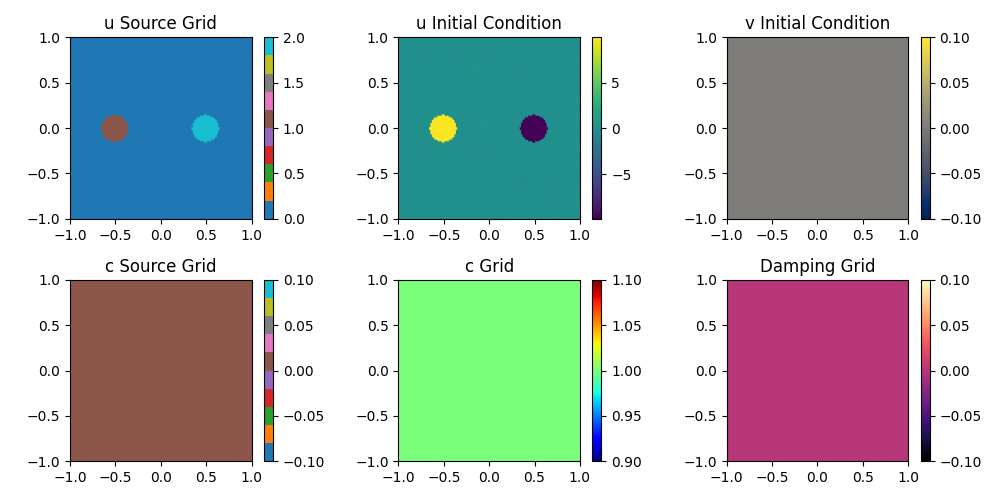

In [34]:
fig, axis = plotInitialState(
    particleState, config,
    uGrid, vGrid, cGrid, dampGrid,
    uSourceGrid, cSourceGrid
)
fig.savefig(f'output/{folderName}/initial_fields.png', dpi = 200)

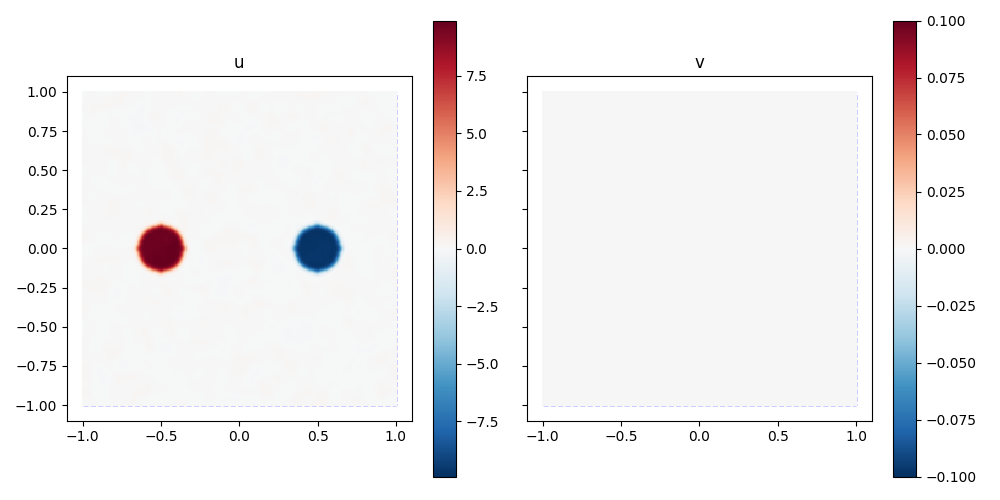

In [35]:
fig, axis, uPlot, vPlot, cPlot, dampPlot = plotState(
    particleState,
    smoothedState,
    config, kernel,
    markerSize = 0.5,
    plotGrid = True,
    plotCD = False)
fig.savefig(f'output/{folderName}/initial_state.png', dpi = 200)

In [ ]:

plotInterval = 10
nIter = 1000
dt = 0.0025
export = True

runSimulation(fig, particleState, uPlot, vPlot, waveSystem, waveSystemFunction, integrator, nx, dt, nIter, kernel, config, export, plotInterval = plotInterval, exportImages = True, umin = -5, umax = 5, vmin = -50, vmax = 50, prefix = prefix, timestamp = timestamp)

  0%|          | 0/1000 [00:00<?, ?it/s]

Creating video from  frames (frame count: 103)
Creating gif palette
Creating gif
Done
